<a href="https://colab.research.google.com/github/Indianinnovation/aegis/blob/main/Lending%20Club%20Loan%20Approval%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lending Club Loan Approval System

## Business Background

Lending Club is a peer-to-peer lending company where individuals can borrow loans, and investors can fund those loans. Lending Club was founded in 2006 by Renaud Laplanche as a peer-to-peer (P2P) lending platform in San Francisco. It was one of the pioneers in the online lending space, where individual borrowers could obtain loans, and individual or institutional investors could invest in these loans to earn interest. The platform allowed for a more direct connection between lenders and borrowers, bypassing traditional banking intermediaries.

Read more here https://en.wikipedia.org/wiki/LendingClub

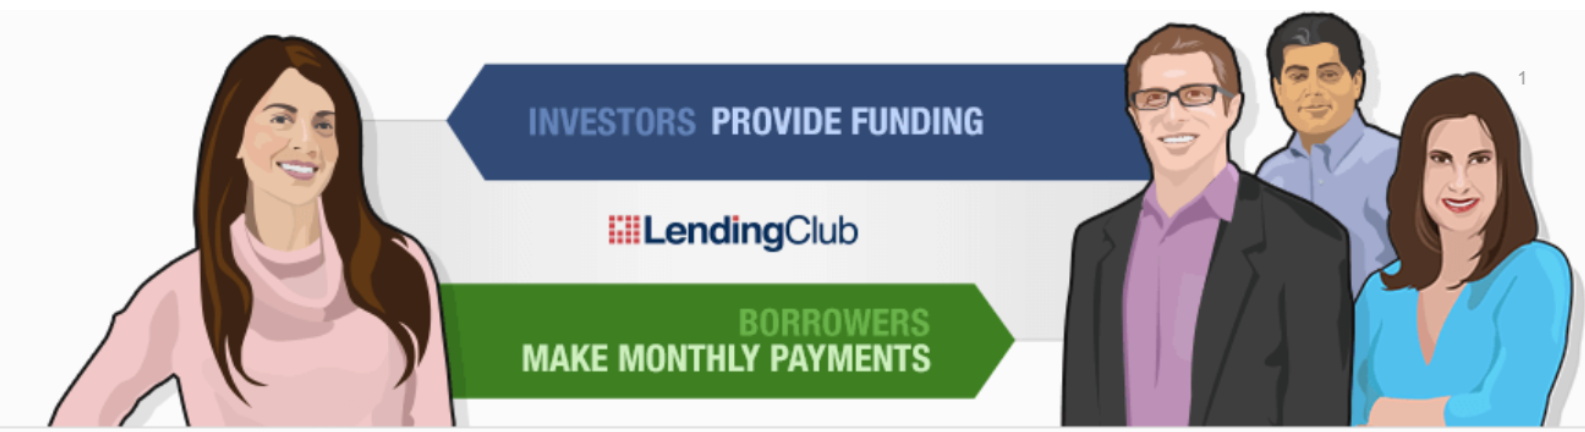

## Problem Statement

Now, whenever *Lending Club* approves a loan, there are two ways in which it is at risk:
- If LC approves a loan and the borrower fails to repay it on time
- If LC rejects a loan despite the borrower being capable of repaying the loan

Defaulting on loans can lead to significant financial losses for both the platform and investors. Similarly, not providing loans to credit-worthy customers can lead to missing out on potential revenue and profits. Therefore, a robust loan approval system is the need of the hour.

In the current loan approval process, underwriters evaluate loan applications by manually reviewing credit scores, income, debt, etc. and then, based on several parameters, either approve or reject a loan. This process is time-consuming and prone to errors.

Hence, Lending Club wants to build a loan approval system using Machine Learning models to automatically assess whether a given loan is likely to be repaid or whether the borrower is likely to default.

This is where you come in! As a budding data scientist, your goal is to help out Lending Club in creating this ML model that helps them predict whether a loan is likely to default or not.

## Data Understanding

You have been provided with around 38k loan application data from the Lending Club's website. The different columns and their description are mentioned below:

| Column Name         | Description                                                                                                                                                    |
|---------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------|
| id                  | A unique LC assigned ID for the loan listing. *(Integer)*                                                                                                       |
| member_id           | A unique LC assigned ID for the borrower member. *(Integer)*                                                                                                    |
| loan_amnt           | The listed amount of the loan applied for by the borrower. If at some point the credit department reduces the loan amount, it will be reflected in this value. *(Float)* |
| term                | The number of payments on the loan. Values are in months and can be either 36 or 60. *(Integer)*                                                                 |
| int_rate            | Interest rate on the loan. *(Float)*                                                                                                                            |
| installment         | The monthly payment owed by the borrower if the loan originates. *(Float)*                                                                                       |
| grade               | LC assigned loan grade. *(Categorical/String)*                                                                                                                  |
| sub_grade           | LC assigned loan subgrade. *(Categorical/String)*                                                                                                               |
| emp_length          | Employment length in years. Possible values are between 0 and 10, where 0 means less than one year and 10 means ten or more years. *(Integer)*                   |
| home_ownership      | The home ownership status provided by the borrower during registration. Values are: RENT, OWN, MORTGAGE, OTHER. *(Categorical/String)*                           |
| annual_inc          | The self-reported annual income provided by the borrower during registration. *(Float)*                                                                         |
| verification_status | Indicates if income was verified by LC, not verified, or if the income source was verified. *(Categorical/String)*                                               |
| purpose             | A category provided by the borrower for the loan request. *(Categorical/String)*                                                                                |
| dti                 | A ratio calculated using the borrower’s total monthly debt payments (excluding mortgage and the requested LC loan), divided by the borrower’s self-reported income. *(Float)* |
| delinq_2yrs         | The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years. *(Integer)*                                         |
| inq_last_6mths      | The number of inquiries in the past 6 months (excluding auto and mortgage inquiries). *(Integer)*                                                                |
| open_acc            | The number of open credit lines in the borrower's credit file. *(Integer)*                                                                                       |
| pub_rec             | Number of derogatory public records. *(Integer)*                                                                                                                |
| revol_bal           | Total credit revolving balance. *(Float)*                                                                                                                       |
| revol_util          | Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit. *(Float)*                             |
| total_acc           | The total number of credit lines currently in the borrower's credit file. *(Integer)*                                                                            |
| last_pymnt_amnt     | Last total payment amount received. *(Float)*                                                                                                                   |
| loan_status         | Current status of the loan. *(Categorical/String)*                                                                 
                  |

...

## Starter Code

### Necessary Imports

In [ ]:
import warnings                          # Python's built-in warnings module
warnings.filterwarnings("ignore")        # Suppress non-critical warning messages so output stays clean

import numpy as np                       # NumPy – fast numerical arrays and math operations
import pandas as pd                      # Pandas – load, clean, and manipulate tabular data (DataFrames)
import matplotlib.pyplot as plt          # Matplotlib – draw static charts and figures
import seaborn as sns                    # Seaborn – prettier statistical visualisations built on Matplotlib

In [ ]:
from sklearn.model_selection import (
    train_test_split,       # Splits data into training and testing sets
    StratifiedKFold,        # K-Fold cross-validation that preserves class ratios in each fold
    cross_val_score,        # Runs cross-validation and returns an array of scores
)

In [ ]:
from sklearn.preprocessing import (
    LabelEncoder,           # Converts text labels like "Yes"/"No" into integers 0/1
    StandardScaler,         # Scales numeric features to mean=0, std=1 (z-score normalisation)
    OneHotEncoder,          # Converts a categorical column into multiple 0/1 binary columns
)

In [ ]:
from sklearn.linear_model import LogisticRegression   # Simple, interpretable linear classification model
from sklearn.ensemble import (
    RandomForestClassifier,       # Ensemble of decision trees – votes for the majority class
    GradientBoostingClassifier,   # Builds trees sequentially; each one corrects the previous one's errors
)

In [ ]:
from sklearn.metrics import (
    classification_report,        # Prints precision, recall, F1 for every class
    confusion_matrix,             # Table showing True/False Positives and Negatives
    roc_auc_score,                # Area Under the ROC Curve – higher is better (max = 1.0)
    roc_curve,                    # Returns (fpr, tpr) points to draw the ROC curve
    ConfusionMatrixDisplay,       # Helper to draw a coloured confusion matrix plot
    precision_recall_curve,       # Returns (precision, recall) points to draw the PR curve
    average_precision_score,      # Area Under the Precision-Recall Curve (good for imbalanced data)
    accuracy_score,               # Fraction of predictions that were correct
    f1_score,                     # Harmonic mean of precision and recall
    recall_score,                 # How many actual positives were caught
    precision_score,              # How many predicted positives were actually correct
)

In [ ]:
from sklearn.pipeline import Pipeline              # Chains multiple steps (imputer → scaler) into one object
from sklearn.impute import SimpleImputer           # Fills in missing values (NaN) with mean/median/mode
from sklearn.compose import ColumnTransformer      # Applies different transformers to different columns


In [ ]:
# --- Optional: XGBoost (eXtreme Gradient Boosting) ---
# We wrap the import in try/except so the script doesn't crash if XGBoost isn't installed.
try:
    from xgboost import XGBClassifier      # XGBoost – very fast, high-performance gradient boosting
    XGBOOST_AVAILABLE = True               # Flag: we can use XGBoost
except ImportError:
    XGBOOST_AVAILABLE = False              # Flag: XGBoost is missing; we'll skip it gracefully
    print("[INFO] XGBoost not installed – skipping XGBClassifier.")

# --- Optional: SMOTE for handling class imbalance ---
# SMOTE creates synthetic minority-class samples so the model doesn't ignore rare defaults.
try:
    from imblearn.over_sampling import SMOTE   # SMOTE = Synthetic Minority Over-sampling Technique
    SMOTE_AVAILABLE = True                     # Flag: imbalanced-learn is installed
except ImportError:
    SMOTE_AVAILABLE = False                    # Flag: not installed; we'll use class_weight instead
    print("[INFO] imbalanced-learn not installed – using class_weight only.")


### Data Loading

In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 1 — LOAD DATA
# Read the Excel file into a Pandas DataFrame.
# ──────────────────────────────────────────────────────────────

DATA_PATH = "/content/loans.xlsx"          # Path to the uploaded dataset (change if stored elsewhere)

df = pd.read_excel(DATA_PATH)     # Read the entire Excel file; df now holds all 38,770 rows

# Print a quick summary so we know the data loaded correctly
print(f"\n{'='*60}")
print(f" Dataset shape  : {df.shape}")              # (rows, columns)
print(f" Columns        : {df.columns.tolist()}")   # List every column name
print(f"{'='*60}\n")


 Dataset shape  : (38770, 23)
 Columns        : ['id', 'member_id', 'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'last_pymnt_amnt', 'loan_status']



# ──────────────────────────────────────────────────────────────
# SECTION 2 — EXPLORATORY DATA ANALYSIS (EDA)
# We look at the data visually BEFORE modelling to understand
# its distribution, balance, and feature relationships.



--- Target Distribution ---
loan_status
Fully Paid     33136
Charged Off     5634
Name: count, dtype: int64
loan_status
Fully Paid     0.855
Charged Off    0.145
Name: proportion, dtype: float64


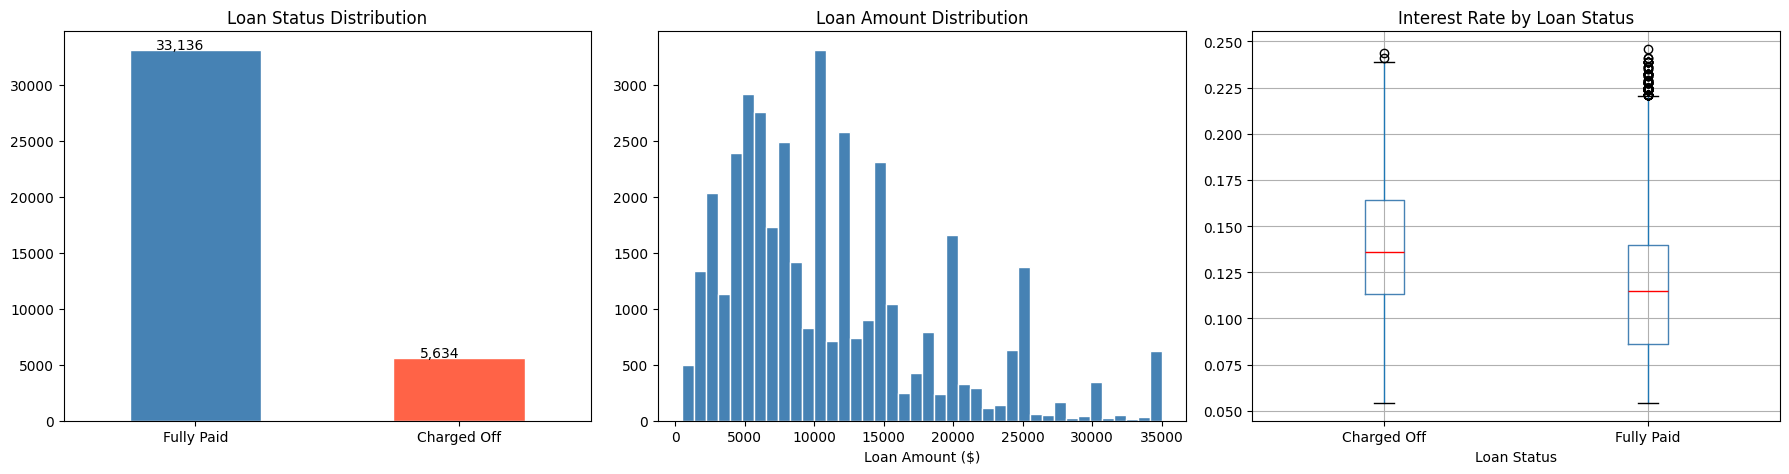

[Saved] eda_overview.png



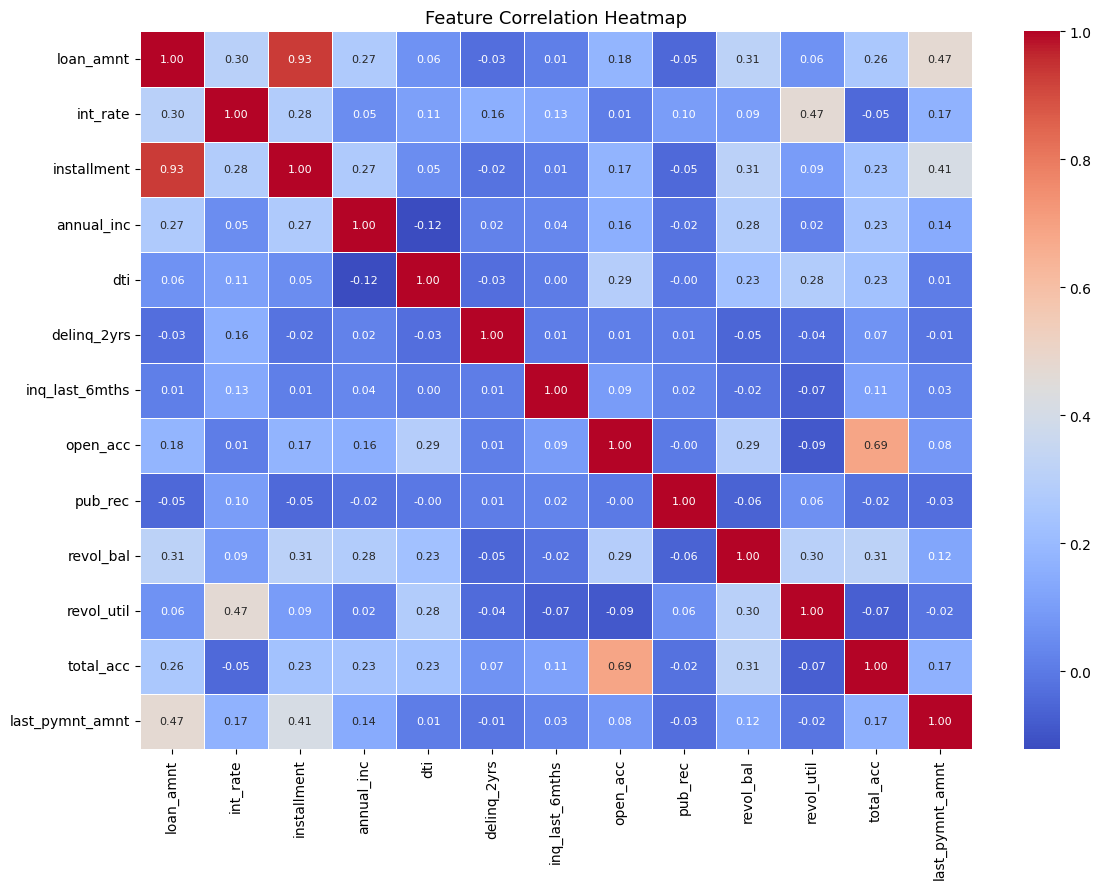

[Saved] correlation_heatmap.png



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 2 — EXPLORATORY DATA ANALYSIS (EDA)
# We look at the data visually BEFORE modelling to understand
# its distribution, balance, and feature relationships.
# ──────────────────────────────────────────────────────────────

# --- 2a. Target Distribution ---
# How many loans are "Fully Paid" vs "Charged Off"?
print("--- Target Distribution ---")
print(df["loan_status"].value_counts())                              # Absolute counts
print(df["loan_status"].value_counts(normalize=True).round(3))      # As percentages

# Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))             # 1 row, 3 columns, 18×5 inches
fig.suptitle("Lending Club – EDA Overview", fontsize=14, fontweight="bold")   # Main title

# --- Plot 1: Target class balance bar chart ---
df["loan_status"].value_counts().plot(
    kind="bar",                              # Vertical bar chart
    ax=axes[0],                              # Draw on the first subplot
    color=["steelblue", "tomato"],           # Blue = Fully Paid, Red = Charged Off
    edgecolor="white"                        # White border between bars for clarity
)
axes[0].set_title("Loan Status Distribution")   # Subplot title
axes[0].set_xlabel("")                           # Remove default x-axis label
axes[0].set_xticklabels(["Fully Paid", "Charged Off"], rotation=0)   # Human-readable labels
for p in axes[0].patches:                       # Loop over every bar in the chart
    axes[0].annotate(                           # Add the exact count as text above each bar
        f"{int(p.get_height()):,}",             # Format number with commas, e.g. "33,136"
        (p.get_x() + 0.1, p.get_height() + 100)  # (x position, y position) for the label
    )

# --- Plot 2: Loan amount histogram ---
axes[1].hist(
    df["loan_amnt"],      # The loan_amnt column values
    bins=40,              # Divide the range into 40 equal-width buckets
    color="steelblue",
    edgecolor="white"
)
axes[1].set_title("Loan Amount Distribution")
axes[1].set_xlabel("Loan Amount ($)")

# --- Plot 3: Interest rate boxplot split by loan status ---
# A boxplot shows median, quartiles, and outliers — great for spotting differences between groups.
df.boxplot(
    column="int_rate",        # The feature we want to compare
    by="loan_status",         # One box per unique loan_status value
    ax=axes[2],
    boxprops=dict(color="steelblue"),    # Box line colour
    medianprops=dict(color="red")        # Median line colour
)
axes[2].set_title("Interest Rate by Loan Status")
axes[2].set_xlabel("Loan Status")
plt.suptitle("")             # Remove the auto-generated "Grouped by" title Pandas adds
plt.tight_layout()           # Adjust spacing so subplots don't overlap
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")   # Save to disk at 120 DPI
plt.show()                   # Display in notebook / IDE
print("[Saved] eda_overview.png\n")

# --- 2b. Correlation Heatmap ---
# A heatmap shows how strongly every numeric feature is linearly correlated with every other.
# Values close to +1 or -1 mean strong relationships; near 0 means little correlation.

num_cols = df.select_dtypes(include=["number"]).columns.tolist()  # Keep only numeric columns
num_cols = [c for c in num_cols if c not in ["id", "member_id"]]  # Drop ID columns (not useful)

plt.figure(figsize=(12, 9))                    # Set figure size
corr = df[num_cols].corr()                     # Compute the Pearson correlation matrix
sns.heatmap(
    corr,
    annot=True,                # Print the correlation value inside each cell
    fmt=".2f",                 # Show 2 decimal places
    cmap="coolwarm",           # Red = positive correlation, Blue = negative
    linewidths=0.5,            # Thin lines separating cells
    annot_kws={"size": 8}      # Font size for the numbers inside cells
)
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("[Saved] correlation_heatmap.png\n")



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 3 — FEATURE ENGINEERING & PREPROCESSING
# Transform raw columns into a numeric format that ML models
# can understand, and remove any columns that would mislead.
# ──────────────────────────────────────────────────────────────

# --- 3a. Drop irrelevant / data-leakage columns ---
# `last_pymnt_amnt` is recorded AFTER the loan outcome is known → it leaks the answer.
# `id` and `member_id` are just identifiers with no predictive value.
DROP_COLS = ["id", "member_id", "last_pymnt_amnt"]
df = df.drop(columns=DROP_COLS)            # Remove these columns permanently from the DataFrame
print(f"Dropped columns: {DROP_COLS}")

# --- 3b. Encode the target variable ---
# ML models need numbers. We convert the text labels to 0 and 1.
df["loan_status"] = df["loan_status"].map({
    "Fully Paid": 1,    # 1 = loan was repaid successfully (positive outcome)
    "Charged Off": 0    # 0 = borrower defaulted (negative outcome we want to detect)
})

# --- 3c. Clean the `term` column ---
# Currently looks like "36 months" or "60 months" (string).
# We extract only the number so models treat it as a numeric duration.
df["term"] = df["term"].str.extract(r"(\d+)").astype(int)
# str.extract(r"(\d+)") → finds the first group of digits in the string ("36")
# .astype(int)          → converts "36" (string) to 36 (integer)

# --- 3d. Clean the `emp_length` column ---
# Currently looks like "10+ years", "< 1 year", "3 years" (string).
# We map each text value to a sensible integer so the model understands ordering.
emp_map = {
    "< 1 year": 0,    # Less than 1 year of employment
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10   # 10 or more years of employment
}
df["emp_length"] = df["emp_length"].map(emp_map)
# Any value NOT in emp_map (e.g. NaN from missing data) will become NaN — handled later by imputer

# --- 3e. Ordinal-encode `grade` and `sub_grade` ---
# Loan grades go A (lowest risk) → G (highest risk).
# Ordinal encoding preserves this ordering (A=0, B=1, …, G=6).

grades = sorted(df["grade"].dropna().unique().tolist())     # ['A','B','C','D','E','F','G']
df["grade_encoded"] = df["grade"].map(
    {g: i for i, g in enumerate(grades)}   # dict comprehension: {'A':0, 'B':1, ..., 'G':6}
)

sub_grades = sorted(df["sub_grade"].dropna().unique().tolist())  # ['A1','A2',...,'G5']
df["sub_grade_encoded"] = df["sub_grade"].map(
    {g: i for i, g in enumerate(sub_grades)}   # {'A1':0, 'A2':1, ..., 'G5':34}
)

df = df.drop(columns=["grade", "sub_grade"])  # Remove the original text columns (replaced by encoded ones)

# --- 3f. Define which columns are numerical vs. categorical ---
TARGET = "loan_status"      # The column we want to predict

# Numerical columns: already numbers (or just converted to numbers above)
NUMERICAL_COLS = [
    "loan_amnt",        # Requested loan amount in dollars
    "term",             # Repayment period in months (36 or 60)
    "int_rate",         # Annual interest rate as a decimal
    "installment",      # Monthly payment amount
    "emp_length",       # Employment length in years (0–10)
    "annual_inc",       # Borrower's self-reported annual income
    "dti",              # Debt-to-Income ratio (total debt / annual income)
    "delinq_2yrs",      # Number of past delinquencies in the last 2 years
    "inq_last_6mths",   # Number of credit inquiries in the last 6 months
    "open_acc",         # Number of currently open credit accounts
    "pub_rec",          # Number of derogatory public records (bankruptcies etc.)
    "revol_bal",        # Total revolving credit balance
    "revol_util",       # Revolving credit utilisation ratio (balance / limit)
    "total_acc",        # Total number of credit lines ever opened
    "grade_encoded",    # Loan grade converted to integer (A=0 … G=6)
    "sub_grade_encoded" # Sub-grade converted to integer (A1=0 … G5=34)
]

# Categorical columns: text values that need one-hot encoding (not ordinal)
CATEGORICAL_COLS = [
    "home_ownership",        # RENT / OWN / MORTGAGE / OTHER
    "verification_status",   # Not Verified / Source Verified / Verified
    "purpose",               # Reason for the loan: debt_consolidation, car, home_improvement, etc.
]

print(f"\nNumerical features  ({len(NUMERICAL_COLS)}) : {NUMERICAL_COLS}")
print(f"Categorical features({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}\n")

# Separate features (X) from the target label (y)
X = df[NUMERICAL_COLS + CATEGORICAL_COLS]   # Input matrix: all feature columns
y = df[TARGET]                              # Output vector: 0 or 1 for each row

print(f"X shape: {X.shape}  |  Class balance:\n{y.value_counts()}\n")



Dropped columns: ['id', 'member_id', 'last_pymnt_amnt']

Numerical features  (16) : ['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'grade_encoded', 'sub_grade_encoded']
Categorical features(3): ['home_ownership', 'verification_status', 'purpose']

X shape: (38770, 19)  |  Class balance:
loan_status
1    33136
0     5634
Name: count, dtype: int64



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 4 — PREPROCESSING PIPELINE
# A Pipeline chains steps so they can't accidentally be applied
# out-of-order or fitted on test data (which would cause data leakage).
# ──────────────────────────────────────────────────────────────

# --- Pipeline for numerical columns ---
numeric_transformer = Pipeline([
    # Step 1 — Imputation: replace missing values (NaN) with the column's median
    # We use median (not mean) because it's more robust to outliers like very large incomes.
    ("imputer", SimpleImputer(strategy="median")),

    # Step 2 — Scaling: subtract mean and divide by std so every feature has mean=0, std=1
    # This prevents large-valued features (like annual_inc in thousands) from dominating
    # small-valued ones (like delinq_2yrs which is 0–5).
    ("scaler",  StandardScaler()),
])

# --- Pipeline for categorical columns ---
categorical_transformer = Pipeline([
    # Step 1 — Imputation: fill missing text values with the most common value in that column
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2 — One-Hot Encoding: convert each text category into a separate 0/1 binary column
    # e.g. home_ownership="RENT" → home_ownership_RENT=1, home_ownership_OWN=0, ...
    # handle_unknown="ignore" means unseen categories at test time become all-zeros (safe default)
    # sparse_output=False returns a regular NumPy array instead of a sparse matrix
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- Combine both pipelines using ColumnTransformer ---
# ColumnTransformer applies each sub-pipeline ONLY to the columns specified.
# Columns not listed are dropped by default.
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     NUMERICAL_COLS),    # Apply numeric pipeline to numeric cols
    ("cat", categorical_transformer, CATEGORICAL_COLS),  # Apply categorical pipeline to cat cols
])



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 4 — PREPROCESSING PIPELINE
# A Pipeline chains steps so they can't accidentally be applied
# out-of-order or fitted on test data (which would cause data leakage).
# ──────────────────────────────────────────────────────────────

# --- Pipeline for numerical columns ---
numeric_transformer = Pipeline([
    # Step 1 — Imputation: replace missing values (NaN) with the column's median
    # We use median (not mean) because it's more robust to outliers like very large incomes.
    ("imputer", SimpleImputer(strategy="median")),

    # Step 2 — Scaling: subtract mean and divide by std so every feature has mean=0, std=1
    # This prevents large-valued features (like annual_inc in thousands) from dominating
    # small-valued ones (like delinq_2yrs which is 0–5).
    ("scaler",  StandardScaler()),
])

# --- Pipeline for categorical columns ---
categorical_transformer = Pipeline([
    # Step 1 — Imputation: fill missing text values with the most common value in that column
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2 — One-Hot Encoding: convert each text category into a separate 0/1 binary column
    # e.g. home_ownership="RENT" → home_ownership_RENT=1, home_ownership_OWN=0, ...
    # handle_unknown="ignore" means unseen categories at test time become all-zeros (safe default)
    # sparse_output=False returns a regular NumPy array instead of a sparse matrix
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- Combine both pipelines using ColumnTransformer ---
# ColumnTransformer applies each sub-pipeline ONLY to the columns specified.
# Columns not listed are dropped by default.
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     NUMERICAL_COLS),    # Apply numeric pipeline to numeric cols
    ("cat", categorical_transformer, CATEGORICAL_COLS),  # Apply categorical pipeline to cat cols
])



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 5 — TRAIN / TEST SPLIT
# Split the dataset: 80% for training, 20% for final evaluation.
# stratify=y ensures both splits keep the same class ratio (85% Paid / 15% Default).
# ──────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Feature matrix
    y,                  # Target vector
    test_size=0.20,     # 20% → test set  |  80% → training set
    random_state=42,    # Seed for reproducibility (same split every run)
    stratify=y,         # Preserve class ratio in both subsets
)
print(f"Train set: {X_train.shape}  |  Test set: {X_test.shape}")


Train set: (31016, 19)  |  Test set: (7754, 19)


In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 6 — OPTIONAL SMOTE (handle class imbalance)
# The dataset has ~6× more "Fully Paid" than "Charged Off".
# Without correction, models learn to mostly predict "Paid" and miss defaults.
# SMOTE synthesises new minority-class (Charged Off) samples to balance the training set.
# ──────────────────────────────────────────────────────────────

# First, apply the preprocessor to convert all text/NaN into clean numeric arrays
X_train_proc = preprocessor.fit_transform(X_train)   # fit_transform: learn statistics ON train only
X_test_proc  = preprocessor.transform(X_test)        # transform only: use stats learned from train

if SMOTE_AVAILABLE:
    smote = SMOTE(
        random_state=42,            # Reproducible synthetic sample generation
        sampling_strategy=0.5       # Create enough synthetic minority samples so
                                    # minority:majority = 0.5 (i.e. 1 default per 2 paid)
    )
    # fit_resample returns a NEW, balanced training set (X and y)
    X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)
    print(f"\nAfter SMOTE — Train class balance:\n{pd.Series(y_train_res).value_counts()}\n")
else:
    # Without SMOTE, we'll rely on class_weight="balanced" inside each model
    X_train_res, y_train_res = X_train_proc, y_train   # Use the original imbalanced data
    print("\n[INFO] SMOTE skipped — using class_weight='balanced' instead.\n")




After SMOTE — Train class balance:
loan_status
1    26509
0    13254
Name: count, dtype: int64



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 7 — MODEL DEFINITIONS
# We define four models. Each has hyperparameters tuned to handle
# the imbalance and the scale of this dataset.
# ──────────────────────────────────────────────────────────────

# Calculate the class imbalance ratio (used by XGBoost's scale_pos_weight)
neg = (y_train == 0).sum()   # Number of Charged Off (minority class)
pos = (y_train == 1).sum()   # Number of Fully Paid (majority class)
scale = neg / pos            # Ratio ≈ 0.17 → tells XGBoost how much to up-weight the minority

models = {
    # ── Model 1: Logistic Regression ──
    # Fast, interpretable, good baseline. Finds a linear boundary between classes.
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",  # Automatically up-weights minority class samples
        max_iter=1000,            # More iterations needed for convergence on large data
        random_state=42,
        C=0.5,                    # Regularisation strength: smaller C = stronger regularisation
    ),

    # ── Model 2: Random Forest ──
    # Ensemble of 200 independent decision trees; majority vote determines the prediction.
    "Random Forest": RandomForestClassifier(
        n_estimators=200,         # Build 200 trees (more trees = more stable but slower)
        class_weight="balanced",  # Each tree sees balanced class weights
        max_depth=12,             # Each tree can grow at most 12 levels deep (avoids overfitting)
        min_samples_leaf=10,      # Each leaf node must have at least 10 samples (smooths the model)
        random_state=42,
        n_jobs=-1,                # Use all available CPU cores to train in parallel
    ),

    # ── Model 3: Gradient Boosting ──
    # Builds trees sequentially; each new tree focuses on the errors of the previous trees.
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,         # Number of boosting rounds (trees)
        learning_rate=0.05,       # How much each tree corrects the previous: small = careful learning
        max_depth=5,              # Shallow trees to prevent overfitting
        subsample=0.8,            # Each tree is trained on 80% of the data (adds randomness)
        random_state=42,
    ),
}

# ── Model 4: XGBoost (added only if installed) ──
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,          # More trees because XGBoost converges slower
        learning_rate=0.05,        # Same careful learning rate
        max_depth=6,               # Slightly deeper trees than sklearn GBM
        scale_pos_weight=scale,    # Handles imbalance: gives more weight to minority class
        use_label_encoder=False,   # Suppress a deprecation warning in newer XGBoost versions
        eval_metric="logloss",     # Internal evaluation metric (log loss = cross-entropy)
        random_state=42,
        n_jobs=-1,                 # Parallelise across all CPU cores
    )



────────────────────────────────────────────────────────────
 Training: Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Charged Off       0.23      0.60      0.33      1127
  Fully Paid       0.91      0.66      0.76      6627

    accuracy                           0.65      7754
   macro avg       0.57      0.63      0.55      7754
weighted avg       0.81      0.65      0.70      7754

ROC-AUC : 0.6865
Avg Precision (PR-AUC): 0.9242

────────────────────────────────────────────────────────────
 Training: Random Forest
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Charged Off       0.28      0.38      0.32      1127
  Fully Paid       0.89      0.83      0.86      6627

    accuracy                           0.76      7754
   macro avg       0.58      0.61      0.59      7754
weighted avg       0.80      0.76      0.78      77

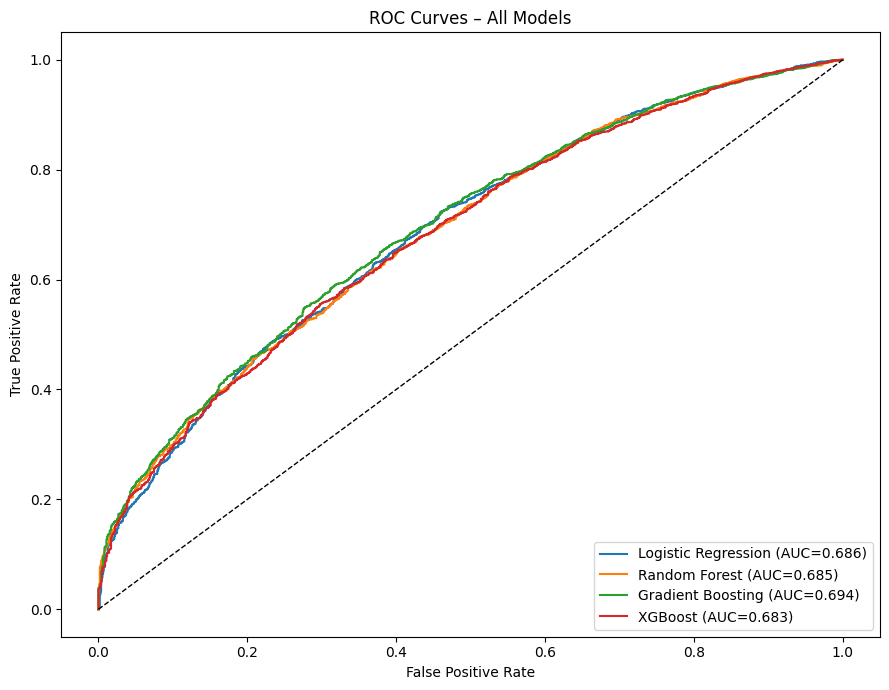

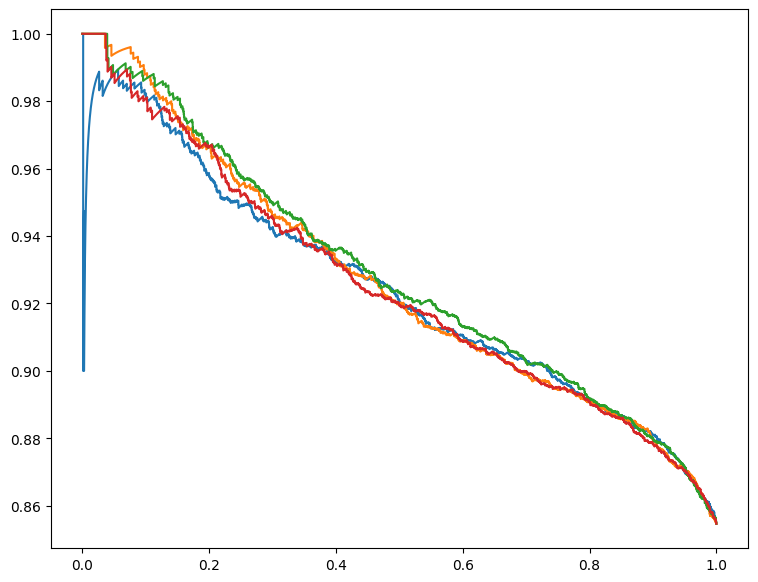

[Saved] roc_curves.png
[Saved] pr_curves.png



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 8 — TRAINING & EVALUATION
# Train every model and compute key metrics on the held-out test set.
# ──────────────────────────────────────────────────────────────

results = {}    # Dictionary to store predictions and scores for each model

# Create two empty figures for ROC and Precision-Recall curves (all models on the same plot)
fig_roc, ax_roc = plt.subplots(figsize=(9, 7))   # ROC curve figure
fig_pr,  ax_pr  = plt.subplots(figsize=(9, 7))   # Precision-Recall figure

for name, model in models.items():   # Iterate over each (model_name, model_object) pair
    print(f"\n{'─'*60}")
    print(f" Training: {name}")
    print(f"{'─'*60}")

    # --- Train the model ---
    model.fit(X_train_res, y_train_res)   # Feed the (possibly SMOTE-augmented) training data

    # --- Predict on the unseen test set ---
    y_pred = model.predict(X_test_proc)       # Hard predictions: 0 or 1 for each test row
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    # predict_proba returns [[prob_class_0, prob_class_1], ...]
    # [:, 1] selects the second column = probability of class 1 (Fully Paid)

    # --- Compute performance metrics ---
    roc_auc  = roc_auc_score(y_test, y_prob)         # AUC-ROC: model's ability to rank positives above negatives
    avg_prec = average_precision_score(y_test, y_prob) # PR-AUC: more informative when classes are imbalanced

    # classification_report prints precision, recall, F1-score per class + weighted averages
    print(classification_report(y_test, y_pred, target_names=["Charged Off", "Fully Paid"]))
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"Avg Precision (PR-AUC): {avg_prec:.4f}")

    # --- Save results for later comparison ---
    results[name] = {
        "model"    : model,       # The trained model object
        "y_pred"   : y_pred,      # Hard predictions (0 or 1)
        "y_prob"   : y_prob,      # Soft predictions (probability of class 1)
        "roc_auc"  : roc_auc,
        "avg_prec" : avg_prec,
    }

    # --- ROC Curve data ---
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    # fpr = False Positive Rates at each threshold
    # tpr = True Positive Rates at each threshold
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")   # One line per model

    # --- Precision-Recall Curve data ---
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ax_pr.plot(recall, precision, label=f"{name} (AP={avg_prec:.3f})")   # One line per model
 # --- Finalise and save the ROC curve plot ---
ax_roc.plot([0, 1], [0, 1], "k--", lw=1)   # Dashed diagonal = random classifier baseline
ax_roc.set_xlabel("False Positive Rate")    # x-axis: fraction of actual negatives wrongly predicted positive
ax_roc.set_ylabel("True Positive Rate")     # y-axis: fraction of actual positives correctly predicted
ax_roc.set_title("ROC Curves – All Models")
ax_roc.legend(loc="lower right")            # Show model names with their AUC values
fig_roc.tight_layout()
fig_roc.savefig("roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("[Saved] roc_curves.png")

# --- Finalise and save the Precision-Recall curve plot ---
ax_pr.set_xlabel("Recall")       # x-axis: sensitivity (how many defaults did we catch?)
ax_pr.set_ylabel("Precision")    # y-axis: exactness (of those we flagged, how many were real defaults?)
ax_pr.set_title("Precision-Recall Curves – All Models")
ax_pr.legend(loc="upper right")
fig_pr.tight_layout()
fig_pr.savefig("pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("[Saved] pr_curves.png\n")



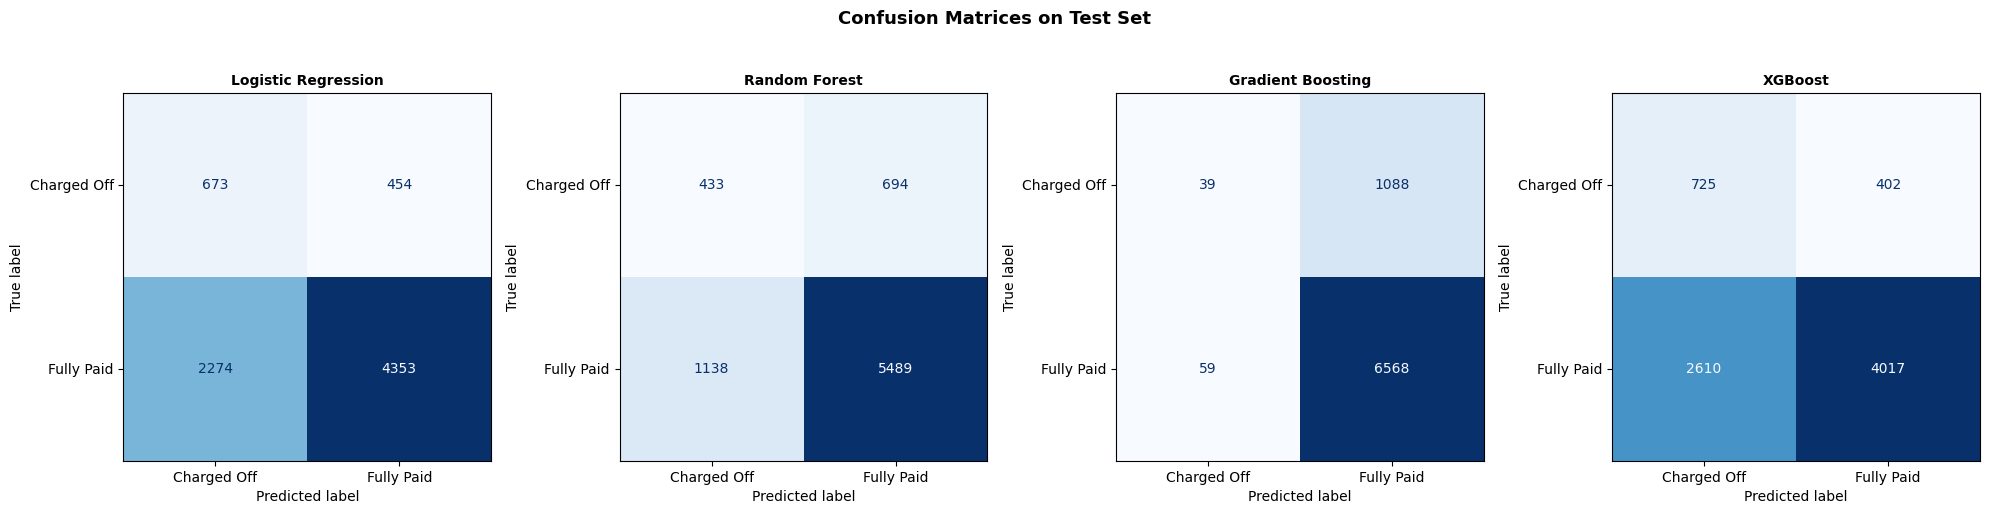

[Saved] confusion_matrices.png



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 9 — CONFUSION MATRICES
# A confusion matrix shows:
#   True Negative  (TN) = Default predicted as Default ✓
#   False Positive (FP) = Default predicted as Paid    ✗ (risky for bank!)
#   False Negative (FN) = Paid predicted as Default    ✗ (missed revenue)
#   True Positive  (TP) = Paid predicted as Paid       ✓
# ──────────────────────────────────────────────────────────────

n_models  = len(results)                                    # How many models we trained
fig_cm, axes_cm = plt.subplots(1, n_models, figsize=(5 * n_models, 5))   # One subplot per model
if n_models == 1:               # If only one model, axes_cm is not a list; wrap it
    axes_cm = [axes_cm]

for ax, (name, res) in zip(axes_cm, results.items()):   # Loop: (subplot_axis, model_name, results)
    cm = confusion_matrix(y_test, res["y_pred"])         # Compute the 2×2 confusion matrix
    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=["Charged Off", "Fully Paid"]    # Human-readable class names
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")       # Draw coloured matrix; no colourbar
    ax.set_title(name, fontsize=10, fontweight="bold")   # Title each subplot with model name

plt.suptitle("Confusion Matrices on Test Set", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()
print("[Saved] confusion_matrices.png\n")



 MODEL COMPARISON SUMMARY
                     Accuracy  Precision (0)  Recall    (0)  F1 (0)  Precision (1)  Recall    (1)  F1 (1)  ROC-AUC  PR-AUC
Model                                                                                                                     
Logistic Regression    0.6482         0.2284         0.5972  0.3304         0.9056         0.6569  0.7614   0.6865  0.9242
Random Forest          0.7637         0.2756         0.3842  0.3210         0.8878         0.8283  0.8570   0.6851  0.9264
Gradient Boosting      0.8521         0.3980         0.0346  0.0637         0.8579         0.9911  0.9197   0.6939  0.9287
XGBoost                0.6116         0.2174         0.6433  0.3250         0.9090         0.6062  0.7273   0.6830  0.9250



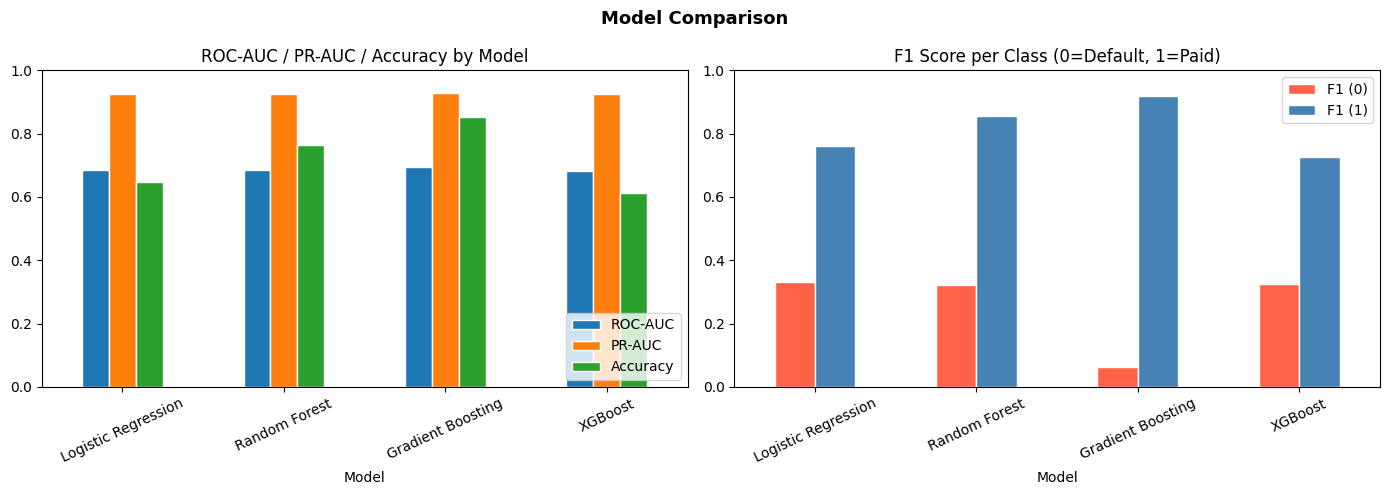

[Saved] model_comparison.png



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 10 — MODEL COMPARISON TABLE
# Build a clean side-by-side summary of every model's performance.
# ──────────────────────────────────────────────────────────────

summary_rows = []   # List to collect one dict per model (will become DataFrame rows)

for name, res in results.items():
    y_pred = res["y_pred"]     # Retrieve hard predictions for this model
    summary_rows.append({
        "Model"         : name,
        # Overall accuracy: fraction of all predictions that were correct
        "Accuracy"      : accuracy_score(y_test, y_pred),
        # Metrics for class 0 (Charged Off = default)
        "Precision (0)" : precision_score(y_test, y_pred, pos_label=0),  # Of loans predicted default, how many really were?
        "Recall    (0)" : recall_score(y_test, y_pred, pos_label=0),      # Of all actual defaults, how many did we catch?
        "F1 (0)"        : f1_score(y_test, y_pred, pos_label=0),           # Harmonic mean of precision & recall for defaults
        # Metrics for class 1 (Fully Paid)
        "Precision (1)" : precision_score(y_test, y_pred, pos_label=1),
        "Recall    (1)" : recall_score(y_test, y_pred, pos_label=1),
        "F1 (1)"        : f1_score(y_test, y_pred, pos_label=1),
        "ROC-AUC"       : res["roc_auc"],
        "PR-AUC"        : res["avg_prec"],
    })

# Convert list of dicts to DataFrame and set "Model" as the row index
summary_df = pd.DataFrame(summary_rows).set_index("Model").round(4)

print("\n" + "="*80)
print(" MODEL COMPARISON SUMMARY")
print("="*80)
print(summary_df.to_string())    # Print without truncation
print("="*80 + "\n")

# --- Bar chart of key metrics per model ---
fig_bar, axes_bar = plt.subplots(1, 2, figsize=(14, 5))   # Two subplots side by side

# Left subplot: ROC-AUC, PR-AUC, and Accuracy grouped by model
summary_df[["ROC-AUC", "PR-AUC", "Accuracy"]].plot(
    kind="bar", ax=axes_bar[0], edgecolor="white", rot=25
)
axes_bar[0].set_title("ROC-AUC / PR-AUC / Accuracy by Model")
axes_bar[0].set_ylim(0, 1)           # y-axis from 0 to 1 (all metrics are fractions)
axes_bar[0].legend(loc="lower right")

# Right subplot: F1 for each class
summary_df[["F1 (0)", "F1 (1)"]].plot(
    kind="bar", ax=axes_bar[1], edgecolor="white",
    color=["tomato", "steelblue"],   # Red = default class, Blue = paid class
    rot=25
)
axes_bar[1].set_title("F1 Score per Class (0=Default, 1=Paid)")
axes_bar[1].set_ylim(0, 1)

plt.suptitle("Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("[Saved] model_comparison.png\n")



Best model by ROC-AUC: Gradient Boosting (0.6939)



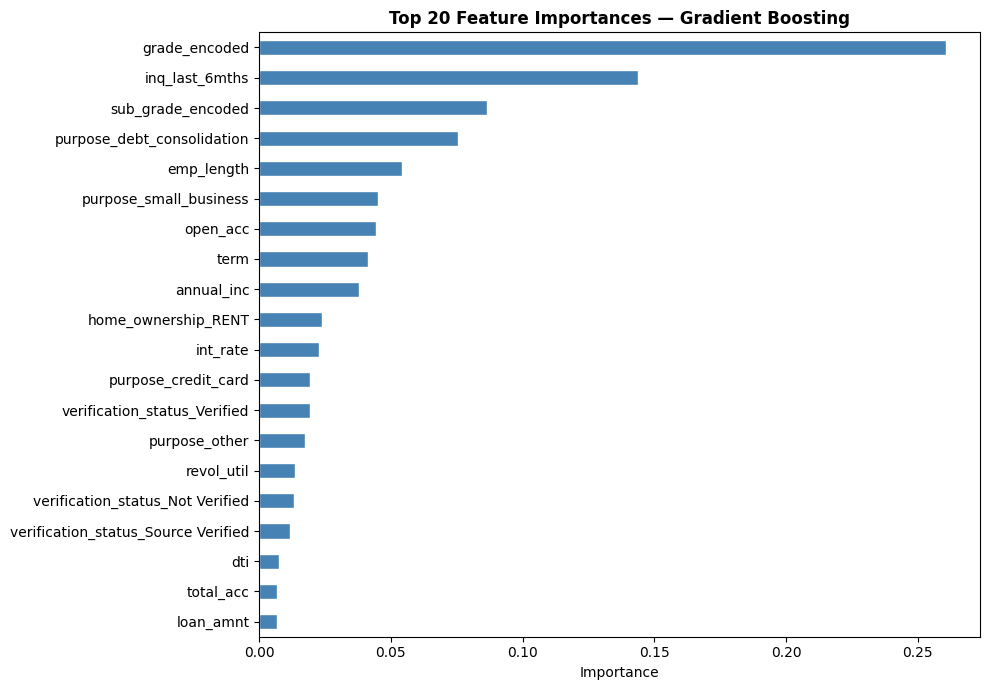

[Saved] feature_importance.png

Top 10 Features:
grade_encoded                 0.260654
inq_last_6mths                0.143826
sub_grade_encoded             0.086486
purpose_debt_consolidation    0.075642
emp_length                    0.054273
purpose_small_business        0.044933
open_acc                      0.044312
term                          0.041480
annual_inc                    0.037940
home_ownership_RENT           0.023814


In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 11 — FEATURE IMPORTANCE
# Which features does the best model rely on most heavily?
# This builds trust and helps business stakeholders understand the model.
# ──────────────────────────────────────────────────────────────

# Find the model with the highest ROC-AUC score
best_name  = max(results, key=lambda k: results[k]["roc_auc"])   # Get model name with max AUC
best_model = results[best_name]["model"]                          # Get the actual trained model
print(f"Best model by ROC-AUC: {best_name} ({results[best_name]['roc_auc']:.4f})\n")

# Tree-based models (RF, GBM, XGBoost) expose feature_importances_
if hasattr(best_model, "feature_importances_"):

    # Retrieve the one-hot encoder inside our preprocessor to get all generated column names
    cat_encoder    = preprocessor.named_transformers_["cat"]["onehot"]  # The OHE step
    ohe_feat_names = cat_encoder.get_feature_names_out(CATEGORICAL_COLS).tolist()
    # e.g. ["home_ownership_MORTGAGE", "home_ownership_OWN", "home_ownership_RENT", ...]

    all_feat_names = NUMERICAL_COLS + ohe_feat_names   # Full list of feature names after encoding

    # Pair each importance score with its feature name
    importances = pd.Series(best_model.feature_importances_, index=all_feat_names)
    top20 = importances.sort_values(ascending=False).head(20)   # Keep only the top 20 features

    plt.figure(figsize=(10, 7))
    top20.sort_values().plot(kind="barh", color="steelblue", edgecolor="white")
    # Horizontal bar chart: longest bar = most important feature
    plt.title(f"Top 20 Feature Importances — {best_name}", fontsize=12, fontweight="bold")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("[Saved] feature_importance.png\n")

    print("Top 10 Features:")
    print(top20.head(10).to_string())

# Logistic Regression uses coefficients instead of importances
elif hasattr(best_model, "coef_"):

    cat_encoder    = preprocessor.named_transformers_["cat"]["onehot"]
    ohe_feat_names = cat_encoder.get_feature_names_out(CATEGORICAL_COLS).tolist()
    all_feat_names = NUMERICAL_COLS + ohe_feat_names

    # |coef| = magnitude of influence; positive → increases Paid probability; negative → decreases it
    coefs = pd.Series(np.abs(best_model.coef_[0]), index=all_feat_names)
    top20 = coefs.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    top20.sort_values().plot(kind="barh", color="steelblue", edgecolor="white")
    plt.title(f"Top 20 Feature Coefficients (|coef|) — {best_name}")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("[Saved] feature_importance.png\n")



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 12 — CROSS-VALIDATION
# Instead of evaluating on a single test split (which could be lucky/unlucky),
# we split the data into 5 folds and evaluate 5 times.
# The average score is a more reliable estimate of real-world performance.
# ──────────────────────────────────────────────────────────────

print(f"\n--- 5-Fold Stratified CV for {best_name} ---")

# StratifiedKFold: each fold has the same class ratio as the full dataset
cv = StratifiedKFold(
    n_splits=5,         # 5 folds = each fold is 20% of data (5 rounds of train/test)
    shuffle=True,       # Shuffle rows before splitting (avoids ordering effects)
    random_state=42
)

# Re-fit the preprocessor on the FULL dataset for CV (not just the 80% train split)
X_all_proc = preprocessor.fit_transform(X)   # Fit & transform all rows

# Run cross-validation: trains and evaluates the best model 5 times
cv_scores = cross_val_score(
    best_model,      # The model to evaluate
    X_all_proc,      # All preprocessed features
    y,               # All target labels
    cv=cv,           # Our 5-fold strategy
    scoring="roc_auc",  # Metric to compute in each fold
    n_jobs=-1,          # Parallelise across all CPU cores
)
print(f"CV ROC-AUC scores : {cv_scores.round(4)}")               # Score for each of the 5 folds
print(f"Mean ± Std        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n")  # Summary




--- 5-Fold Stratified CV for Gradient Boosting ---
CV ROC-AUC scores : [0.7054 0.7163 0.7036 0.7006 0.7085]
Mean ± Std        : 0.7069 ± 0.0054



--- Threshold Tuning for Gradient Boosting (minority = Charged Off) ---


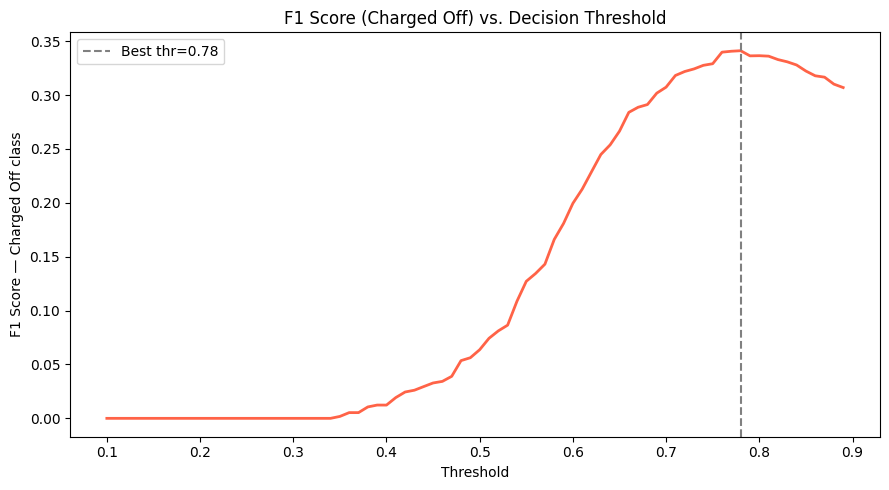

Best threshold for Charged Off F1 : 0.78
Max F1 (Charged Off)              : 0.3411

[Saved] threshold_tuning.png

Classification Report @ threshold=0.78:
              precision    recall  f1-score   support

 Charged Off       0.25      0.53      0.34      1127
  Fully Paid       0.90      0.73      0.81      6627

    accuracy                           0.70      7754
   macro avg       0.58      0.63      0.58      7754
weighted avg       0.81      0.70      0.74      7754



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 13 — THRESHOLD TUNING
# By default, models predict class 1 (Paid) if probability ≥ 0.50.
# But for loan default detection, we might prefer a lower threshold
# to catch MORE defaults at the cost of some false alarms.
# We sweep all thresholds and find the one that maximises F1 for defaults.
# ──────────────────────────────────────────────────────────────

print(f"--- Threshold Tuning for {best_name} (minority = Charged Off) ---")
y_prob_best = results[best_name]["y_prob"]   # Probability of class 1 (Fully Paid) for best model

thresholds     = np.arange(0.1, 0.9, 0.01)  # Test every threshold from 0.10 to 0.89 in steps of 0.01
f1_charged_off = []                          # Store F1 score for Charged Off at each threshold

for thr in thresholds:
    # If model says prob(Paid) >= thr → predict 1 (Paid), else → predict 0 (Default)
    y_pred_thr = (y_prob_best >= thr).astype(int)

    # Compute F1 for the DEFAULT class (pos_label=0)
    f1_co = f1_score(y_test, y_pred_thr, pos_label=0, zero_division=0)
    f1_charged_off.append(f1_co)   # Record this threshold's F1 score

best_thr_idx = np.argmax(f1_charged_off)   # Index of the highest F1 score
best_thr     = thresholds[best_thr_idx]    # The threshold value that gives the best default F1

# Plot F1 vs threshold to visualise the trade-off
plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_charged_off, color="tomato", lw=2)              # F1 curve
plt.axvline(best_thr, linestyle="--", color="gray",
            label=f"Best thr={best_thr:.2f}")                            # Vertical line at best threshold
plt.title("F1 Score (Charged Off) vs. Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score — Charged Off class")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Best threshold for Charged Off F1 : {best_thr:.2f}")
print(f"Max F1 (Charged Off)              : {max(f1_charged_off):.4f}\n")
print("[Saved] threshold_tuning.png\n")

# Print the classification report at the tuned threshold
y_pred_tuned = (y_prob_best >= best_thr).astype(int)   # Apply the tuned threshold
print(f"Classification Report @ threshold={best_thr:.2f}:")
print(classification_report(y_test, y_pred_tuned,
                              target_names=["Charged Off", "Fully Paid"]))



In [ ]:
# ──────────────────────────────────────────────────────────────
# SECTION 14 — SAVE MODEL TO DISK
# Save the trained model and preprocessor so they can be reloaded
# in a production system without retraining.
# ──────────────────────────────────────────────────────────────

try:
    import joblib                                     # joblib serialises Python objects efficiently
    joblib.dump(best_model,   "best_model.pkl")       # Save trained model to "best_model.pkl"
    joblib.dump(preprocessor, "preprocessor.pkl")     # Save preprocessor to "preprocessor.pkl"
    print("[Saved] best_model.pkl  |  preprocessor.pkl")
except Exception as e:
    print(f"[WARN] Could not save model: {e}")        # Non-fatal: script continues even if save fails


# ──────────────────────────────────────────────────────────────
# SECTION 15 — INFERENCE HELPER FUNCTION
# This function lets you feed a single loan application and get
# back a probability and a decision (APPROVE / REJECT).
# ──────────────────────────────────────────────────────────────

def predict_loan(application: dict, threshold: float = best_thr) -> dict:
    """
    Predict default risk for a single new loan application.

    Parameters
    ----------
    application : dict
        A dictionary where each key is a feature name and each value is
        the raw (un-preprocessed) input for that feature.
        All keys in NUMERICAL_COLS and CATEGORICAL_COLS must be present.

    threshold : float
        The decision cut-off.  If prob(Fully Paid) >= threshold → APPROVE.
        Defaults to the threshold tuned in Section 13.

    Returns
    -------
    dict with three keys:
        prob_default    – probability the borrower will default (0–1)
        prob_fully_paid – probability the loan will be fully repaid (0–1)
        decision        – "APPROVE" if low risk, "REJECT" if high risk
    """

    app_df   = pd.DataFrame([application])          # Convert dict to a single-row DataFrame
    app_proc = preprocessor.transform(app_df)       # Apply the SAME preprocessing as during training
                                                     # (uses statistics learned on the training set)

    prob_paid    = best_model.predict_proba(app_proc)[0, 1]   # P(Fully Paid) for this application
    prob_default = 1 - prob_paid                               # P(Charged Off) = 1 − P(Paid)

    # Business rule: approve if the model is confident enough the loan will be repaid
    decision = "APPROVE" if prob_paid >= threshold else "REJECT"

    return {
        "prob_default"   : round(prob_default, 4),    # Round to 4 decimal places for readability
        "prob_fully_paid": round(prob_paid, 4),
        "decision"       : decision,
    }


# ── Demo: run one sample prediction ──
sample_application = {
    # Loan details
    "loan_amnt"          : 10000,   # Applying for a $10,000 loan
    "term"               : 36,      # 36-month repayment term
    "int_rate"           : 0.12,    # 12% annual interest rate
    "installment"        : 332.10,  # Monthly payment of $332.10
    # Borrower profile
    "emp_length"         : 5,       # 5 years of employment (mapped from "5 years")
    "annual_inc"         : 60000,   # $60,000 annual income
    "dti"                : 15.0,    # Debt-to-income ratio of 15%
    # Credit history
    "delinq_2yrs"        : 0,       # No delinquencies in last 2 years
    "inq_last_6mths"     : 1,       # 1 credit inquiry in last 6 months
    "open_acc"           : 5,       # 5 open credit accounts
    "pub_rec"            : 0,       # No public derogatory records
    "revol_bal"          : 5000,    # $5,000 revolving credit balance
    "revol_util"         : 0.45,    # Using 45% of revolving credit limit
    "total_acc"          : 10,      # 10 credit lines ever opened
    "grade_encoded"      : 2,       # Grade C (index 2 in ['A','B','C','D','E','F','G'])
    "sub_grade_encoded"  : 10,      # Sub-grade C1
    # Categorical fields (raw text — preprocessor will handle encoding)
    "home_ownership"     : "RENT",
    "verification_status": "Verified",
    "purpose"            : "debt_consolidation",
}

result = predict_loan(sample_application)   # Call the inference function

print("\n" + "="*50)
print(" DEMO PREDICTION")
print("="*50)
for k, v in result.items():
    print(f"  {k:<20}: {v}")   # Print each key-value pair, left-aligning the key in 20 chars
print("="*50 + "\n")

print("Done. All plots and model artifacts saved to the working directory.")


[Saved] best_model.pkl  |  preprocessor.pkl

 DEMO PREDICTION
  prob_default        : 0.9523
  prob_fully_paid     : 0.0477
  decision            : REJECT

Done. All plots and model artifacts saved to the working directory.


After executing the previous cells, please document your observations here:

In [ ]:
display(df.head())

,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_amnt,loan_status
0,1077501,1296599,5000,36 months,0.1065,162.87,B,B2,10+ years,RENT,...,27.65,0,1,3,0,13648,0.837,9,171.62,Fully Paid
1,1077430,1314167,2500,60 months,0.1527,59.83,C,C4,< 1 year,RENT,...,1.00,0,5,3,0,1687,0.094,4,119.66,Charged Off
2,1077175,1313524,2400,36 months,0.1596,84.33,C,C5,10+ years,RENT,...,8.72,0,2,2,0,2956,0.985,10,649.91,Fully Paid
3,1076863,1277178,10000,36 months,0.1349,339.31,C,C1,10+ years,RENT,...,20.00,0,1,10,0,5598,0.210,37,357.48,Fully Paid
4,1075269,1311441,5000,36 months,0.0790,156.46,A,A4,3 years,RENT,...,11.20,0,3,9,0,7963,0.283,12,161.03,Fully Paid


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38770 entries, 0 to 38769
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   38770 non-null  int64  
 1   member_id            38770 non-null  int64  
 2   loan_amnt            38770 non-null  int64  
 3   term                 38770 non-null  object 
 4   int_rate             38770 non-null  float64
 5   installment          38770 non-null  float64
 6   grade                38770 non-null  object 
 7   sub_grade            38770 non-null  object 
 8   emp_length           37734 non-null  object 
 9   home_ownership       38770 non-null  object 
 10  annual_inc           38770 non-null  float64
 11  verification_status  38770 non-null  object 
 12  purpose              38770 non-null  object 
 13  dti                  38770 non-null  float64
 14  delinq_2yrs          38770 non-null  int64  
 15  inq_last_6mths       38770 non-null 

None

In [ ]:
display(df.shape)

(38770, 23)

In [ ]:
display(df.isnull().sum())

,0
id,0
member_id,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,1036
home_ownership,0


#### Observations

- Document your observations

### Data Cleaning

- Perform missing value treatment
- Remove extra symbols, characters, etc. from appropriate columns

In [ ]:
missing_values_percentage = df_loans.isnull().sum() * 100 / len(df_loans)
print(missing_values_percentage)

id                     0.000000
member_id              0.000000
loan_amnt              0.000000
term                   0.000000
int_rate               0.000000
installment            0.000000
grade                  0.000000
sub_grade              0.000000
emp_length             2.672169
home_ownership         0.000000
annual_inc             0.000000
verification_status    0.000000
purpose                0.000000
dti                    0.000000
delinq_2yrs            0.000000
inq_last_6mths         0.000000
open_acc               0.000000
pub_rec                0.000000
revol_bal              0.000000
revol_util             0.128966
total_acc              0.000000
last_pymnt_amnt        0.000000
loan_status            0.000000
dtype: float64


In [ ]:
#### Observations on Missing Values

#- **`emp_length`**: This column has approximately `2.67%` missing values.
#- **`revol_util`**: This column has approximately `0.13%` missing values.

#Both `emp_length` and `revol_util` have a relatively small percentage of missing values, which can be handled through imputation or by removing the rows if necessary, depending on the chosen strategy. Given the small percentage, imputation might be a suitable approach.

In [ ]:
# Impute missing values in 'emp_length' with the mode
df_loans['emp_length'].fillna(df_loans['emp_length'].mode()[0], inplace=True)
# Impute missing values in 'revol_util' with the median
df_loans['revol_util'].fillna(df_loans['revol_util'].median(), inplace=True)

# Verify that missing values have been handled
print('Missing values after imputation:')
print(df_loans.isnull().sum())

NameError: name 'df_loans' is not defined

In [ ]:
## Write your code


##### Dropping the unnecessary columns

- Columns which are not required for analysis - `id`, `member_id`
- Columns which are not available at the time of loan approval (Check the data dictionary and problem statement to understand this more) - `installment` and `last_pymnt_amnt`

In [ ]:
columns_to_drop = ['id', 'member_id', 'installment', 'last_pymnt_amnt']
df_loans.drop(columns=columns_to_drop, inplace=True)

In [ ]:
display(df_loans.head())

Perform any additional data preparation steps if needed

In [ ]:
## Write the code

In [ ]:
## Write the code

### Exploratory Data Analysis

Let's understand the key drivers of loan default using EDA. This will form the preliminary analysis before we start with our machine learning model building part. We can understand the distributions of different variables, how they are related with loan default and so on.

#### Univariate Analysis

Perform univariate analysis on the following variables. Use visualizations and summary statistics wherever necessary. Document your overall observations as well
- `loan_status`
- `term`
- `grade`
- `purpose`
- `loan_amnt`
- `annual_inc`

*Note* - You can do additional analysis as well

In [ ]:
## Write Code here

In [ ]:
## Write Code here

In [ ]:
## Write Code here

In [ ]:
## Write Code here

In [ ]:
## Write Code here

**Observations**

- The dataset `df_loans` has been successfully loaded with 39,717 rows and 19 columns.
- Some columns appear to have missing values, which will need to be addressed in the data cleaning step.
- Data types seem appropriate for most columns, but some might require further inspection or conversion (e.g., object types that represent categorical data).
- The `head()` display gives us a first look at the range and format of the data in different columns.

#### Bivariate Analysis

For the bivariate analysis, you can perform multiple analysis such as follows:

- How the default rate varies across the different variables
- Correlation Matrix
- etc.

In [ ]:
#Write your code here

In [ ]:
#Write your code here

In [ ]:
#Write your code here

In [ ]:
#Write your code here

In [ ]:
#Write your code here

#### Pre-ML Data Pre-Processing

Before building the machine learning model, we shall perform
- encoding on all the categorical variables
- train-test split
- handle class imbalance
- scaling

##### Encoding variables

In [ ]:
# Write code here

**Train-test split**


In [ ]:
# Write code here

In [ ]:
# Write code here

**Handling Class Imbalance**

Suggestion - Perform SMOTE here

In [ ]:
from imblearn.over_sampling import SMOTE


In [ ]:
## Write code

In [ ]:
## Write code


In [ ]:
## Check the distribution of class in the newly resampled data


In [ ]:
# Splitting our dataset between training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = ## Write code here

In [ ]:
## Check the samples


**Scaling**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Write code for MinMax Scaler


### Model Building and Model Evaluation

- Your task is to build at least 3 models and evaluate their performance
- Start with a baseline model such as logistic regression
- Build additional models like decision trees, random forests, XGboost, etc.
- Make sure you're checking for overfitting and underfitting
- Use cross-validation and hyperparamater tuning to fit the best models
- Evaluate each of the model using metrics such as accuracy, precision, recall, ROC-AUC score, etc.
- Select the best possible model that you will be using for classfication

Let's start off with the simplest model - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
## Build the model
## Check its evaluation metrics

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Plot the Confusion Matrix


In [ ]:
from sklearn.metrics import classification_report
## Plot the classification report

Observations

- Document your observations

Next go ahead and build a decision tree and other models using the similar steps as above

Note
- You can build additional models as well
- Make sure you're performing the necessary steps to evaluate the model

Ensure that the following is done:

- The accuracy/precision/recall of the best model is at least between 80%
- All the necessary hyperparameter tuning, and regularization techniques (if needed) have been applied
- There's no overfitting

## Summary

Good work completing all the steps till now!
Now, go ahead and summarize your entire work and findings below:

-

-

-

---

### **Some Python libraries that are worth exploring for similar projects**
  - **tqdm**: A Python library used to create progress bars for iterables. It provides visual feedback on the progress of long-running operations, making it easier to track the execution time and estimate the remaining time.
  - **Low-code learning libraries** Use lazypredict or PyCaret to compare the performance of multiple Machine Learning models simultaneously. *The best part is that you only need to write fewer than 10 lines of code.*
  - **Explainable AI**: Understand model decisions through techniques like LIME or SHAP.